A idéia desse código prático foi tentar apenas adaptar o código feito no curso de GANs para utilizar o pytorch invés do tensorflow. O objetivo em sí era me familiarizar mais com essa biblioteca que eu tenho tido mais dificuldade para me adaptar do que tive com o tensorflow.

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [29]:
from torch import nn
from torch import optim
from torch.utils.data import ConcatDataset
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

In [30]:
# verifica se tem GPU disponível
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

Usando: cuda


In [31]:
# tamanho do batch dos dados
BATCH_SIZE = 64

# transformando as imagens em tensor e normalizando
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# carregando os dados de treino e teste
train = MNIST(root="./data", train=True, download=True, transform=transform)
test = MNIST(root="./data", train=False, download=True, transform=transform)
# concatenando em um unico dataset
dataset = ConcatDataset([train, test])
dataset

In [32]:
# carregando o dataset em batch
dataset = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
dataset

In [ ]:
# dimensão do ruído
NOISE_DIM = 150

# criando o gerador
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # criação das camadas (utilizei as mesmas dimensões do curso))
        self.model = nn.Sequential(
            nn.Linear(NOISE_DIM, 7 * 7 * 256),
            nn.LeakyReLU(0.2)
        )

        # bloco de convoluções
        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(128, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
      x = self.model(z)
      x = x.view(-1, 256, 7, 7)
      return self.conv_blocks(x)

# instanciando o gerador
generator = Generator().to(device)
print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=150, out_features=12544, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
  )
  (conv_blocks): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)


In [ ]:
# criando o discriminador
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # camada de entrada
            nn.Conv2d(1, 256, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # convolução
            nn.Conv2d(256, 128, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # camada densa
            nn.Flatten(),
            nn.Linear(128*7*7, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.model(x)

# instanciando o discriminador
discriminator = Discriminator().to(device)
print(discriminator)

Discriminator(
  (model): Sequential(
    (0): Conv2d(1, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=6272, out_features=64, bias=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# criando os optimizadores para cada um
optimizer_G = optim.Adam(generator.parameters(),     lr=0.00001, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.00003, betas=(0.5, 0.999))

# calculo da loss
loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
# treinamento do discriminador
def train_discriminator(real_images):
    batch_size = real_images.size(0)

    # 1 para real, 0 para falso
    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # gera imagens falsas
    noise = torch.randn(batch_size, NOISE_DIM).to(device)
    fake_images = generator(noise).detach()  # .detach() = não propaga gradiente pro Generator

    optimizer_D.zero_grad()

    # loss nas imagens reais + loss nas imagens falsas
    loss_real = loss_fn(discriminator(real_images), real_labels)
    loss_fake = loss_fn(discriminator(fake_images), fake_labels)
    d_loss = (loss_real + loss_fake) / 2

    # backpropagation
    d_loss.backward()
    optimizer_D.step()

    return d_loss.item()

# treino do gerador
def train_generator(batch_size):
    # o Generator quer que o Discriminator classifique tudo como real (label=1)
    real_labels = torch.ones(batch_size, 1).to(device)

    noise = torch.randn(batch_size, NOISE_DIM).to(device)

    optimizer_G.zero_grad()

    # calcula a loss
    fake_images = generator(noise)
    g_loss = loss_fn(discriminator(fake_images), real_labels)

    # backpropagation
    g_loss.backward()
    optimizer_G.step()

    return g_loss.item()

In [ ]:
# fazendo o treinamento em 30 épocas
EPOCHS = 30

for epoch in range(EPOCHS):
    # loss acumulada de cada um
    d_loss_sum = 0
    g_loss_sum = 0
    cnt = 0

    for batch_images, _ in dataset:
        real_images = batch_images.to(device)

        # faz o treinamento
        d_loss = train_discriminator(real_images)
        g_loss = train_generator(real_images.size(0))

        # calcula a loss de cada um
        d_loss_sum += d_loss
        g_loss_sum += g_loss
        cnt += 1

    print(f"E:{epoch:02d}, Loss G:{g_loss_sum/cnt:.4f}, Loss D:{d_loss_sum/cnt:.4f}")

E:00, Loss G:8.1887, Loss D:0.0152
E:01, Loss G:11.4900, Loss D:0.0000
E:02, Loss G:12.7724, Loss D:0.0000
E:03, Loss G:14.1592, Loss D:0.0000
E:04, Loss G:14.4629, Loss D:0.0000
E:05, Loss G:15.2153, Loss D:0.0000
E:06, Loss G:16.1289, Loss D:0.0000
E:07, Loss G:17.0847, Loss D:0.0000
E:08, Loss G:16.7600, Loss D:0.0000
E:09, Loss G:17.7330, Loss D:0.0000
E:10, Loss G:18.7474, Loss D:0.0000
E:11, Loss G:13.9458, Loss D:0.0002
E:12, Loss G:13.9226, Loss D:0.0000
E:13, Loss G:15.4426, Loss D:0.0000
E:14, Loss G:15.8915, Loss D:0.0000
E:15, Loss G:16.1486, Loss D:0.0000
E:16, Loss G:17.3567, Loss D:0.0000
E:17, Loss G:18.2715, Loss D:0.0000
E:18, Loss G:19.0097, Loss D:0.0000
E:19, Loss G:19.7608, Loss D:0.0000
E:20, Loss G:20.2113, Loss D:0.0000
E:21, Loss G:21.0563, Loss D:0.0000
E:22, Loss G:16.0852, Loss D:0.0070
E:23, Loss G:5.1758, Loss D:0.0309
E:24, Loss G:5.3210, Loss D:0.0327
E:25, Loss G:4.4091, Loss D:0.0774
E:26, Loss G:3.4299, Loss D:0.1523
E:27, Loss G:2.6032, Loss D:0.222

In [ ]:
# função para plotar as imagens geradas
def plot_images(epoch=None):

    # pegando imagens geradas
    generator.eval()
    with torch.no_grad():
        # ruido aleatório
        noise = torch.randn(81, NOISE_DIM).to(device)
        # gerar imagens aleatórias
        images = generator(noise).cpu()

    # configurações da imagem
    plt.figure(figsize=(9, 9))
    title = f"Época {epoch}" if epoch is not None else "Imagens geradas"
    plt.suptitle(title, fontsize=14)

    # mostrando as imagens geradas
    for i, img in enumerate(images):
        plt.subplot(9, 9, i + 1)
        plt.imshow(img.squeeze(), cmap="Greys_r", vmin=-1, vmax=1)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    generator.train()

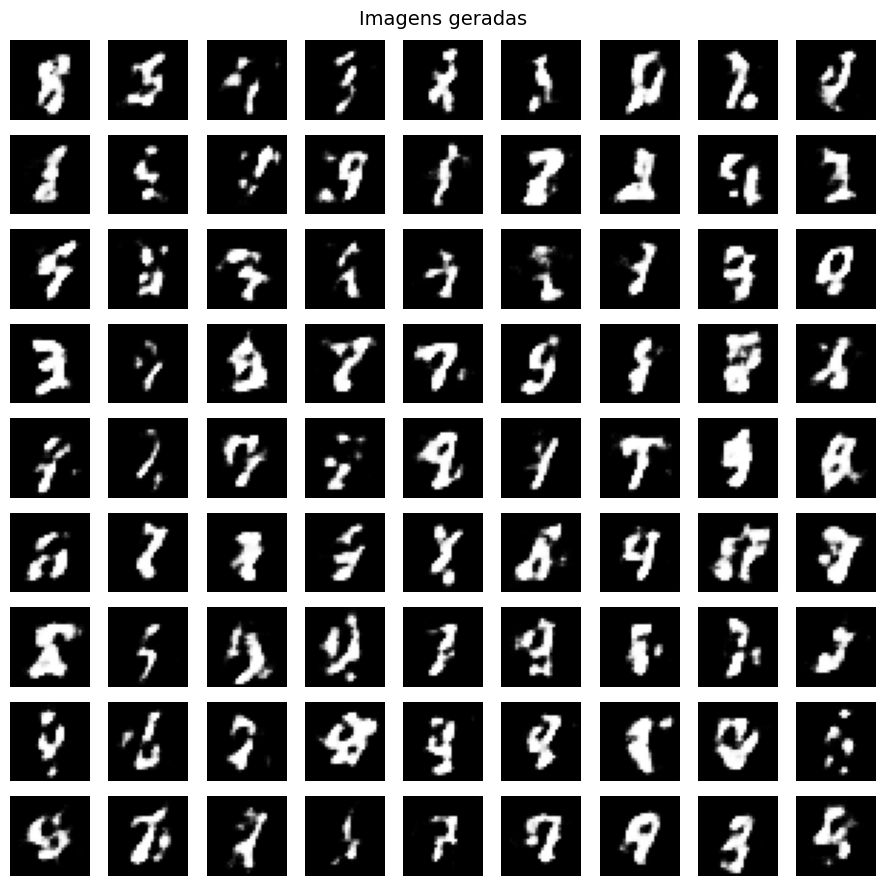

In [39]:
plot_images()